# Two-Sample T-Test

**Module 5: Numerical Outcomes** | Lean Six Sigma Data Analytics

---

## The Story of William Sealy Gosset

This man is called **William Sealy Gosset** and he lived in England around 1900.

He studied chemistry and mathematics, and upon graduating he started to work for the **Guinness Brewery**.

Gosset applied his statistical knowledge to select the best-yielding varieties of barley. He used trials. And as it is obviously very time-consuming to produce barley, he could not do too many trials.

**The problem:** He was faced with only very small samples.

**The solution:** He developed a special test to draw conclusions from small samples and determine which barley had the best yield.

This test is now widely known as the **two-sample t-test**.

For confidentiality reasons, Gosset wasn't allowed to publish under his own name. He was forced to publish his work under the pseudonym **"Student"**.

This is why the two-sample t-test is also known as **Student's t-test**.

> This story shows that statistics is used to solve problems people encounter in their work—not abstract formulas and mathematics.

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for two-sample t-test analysis!')


Ready for two-sample t-test analysis!


---

## What is the Two-Sample T-Test?

The two-sample t-test is a method to **compare means of two groups**.

---

## Example: Tomatoes and Fertilizer

### The Scenario

Imagine you are growing tomatoes and you wish to maximize the **yield** (the total amount of kilograms of tomatoes that you harvest).

You experiment with two different fertilizers: **Fertilizer A** and **Fertilizer B**.

**Question:** Which fertilizer should you choose? Which fertilizer produces more tomatoes?

### The Experiment

1. Take a field and divide it into **20 pieces**
2. Plant tomatoes
3. Randomly select **10 pieces** and put Fertilizer A on them
4. Put Fertilizer B on the other **10 pieces**
5. Wait until tomatoes are grown
6. Harvest and measure the **yield** for each sub-field

In [2]:
# Load fertilizer data
def load_fertilizer():
    df = pd.read_excel(xlsx, sheet_name='Fertilizer', skiprows=7, header=None, usecols=[0, 1])
    df.columns = ['Fertilizer_A', 'Fertilizer_B']
    return df.dropna()

fertilizer = load_fertilizer()

print('FERTILIZER EXPERIMENT DATA')
print('=' * 50)
print()
fertilizer

FERTILIZER EXPERIMENT DATA



,Fertilizer_A,Fertilizer_B
0,7.8,10.9
1,5.1,4.3
2,5.7,9.1
3,2.3,5.2
4,2.9,6.2
5,8.2,11.3
6,7.8,9.4
7,5.4,8.1
8,4.5,8.6
9,6.9,10.9


---

## Visualize the Data

Which fertilizer will you use?

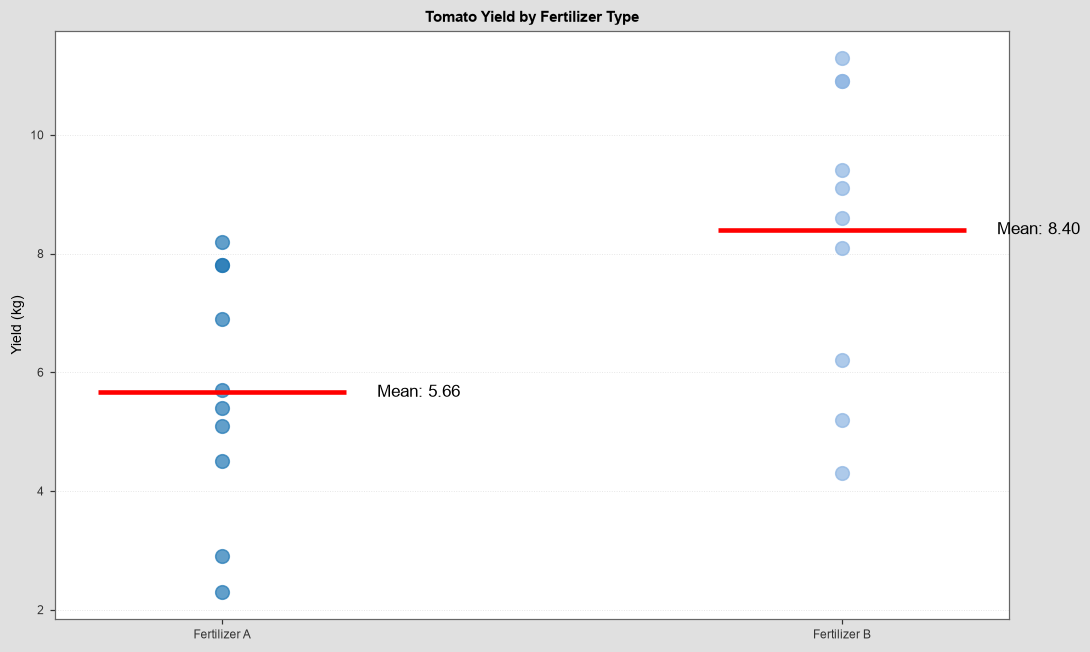

OBSERVATION:
  Mean yield of Fertilizer A: 5.66 kg
  Mean yield of Fertilizer B: 8.40 kg

  Fertilizer B results in a higher yield on average.


In [3]:
# Visualize the data
fig, ax = plt.subplots(figsize=(10, 6))

# Plot individual points
for i, col in enumerate(['Fertilizer_A', 'Fertilizer_B']):
    data = fertilizer[col]
    ax.scatter([i]*len(data), data, s=80, alpha=0.7)
    # Add mean line
    mean = data.mean()
    ax.hlines(mean, i-0.2, i+0.2, colors='red', linewidths=3)
    ax.text(i+0.25, mean, f'Mean: {mean:.2f}', va='center', fontsize=11)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Fertilizer A', 'Fertilizer B'])
ax.set_ylabel('Yield (kg)')
ax.set_title('Tomato Yield by Fertilizer Type')

plt.tight_layout()
plt.show()

mean_a = fertilizer['Fertilizer_A'].mean()
mean_b = fertilizer['Fertilizer_B'].mean()

print('OBSERVATION:')
print(f'  Mean yield of Fertilizer A: {mean_a:.2f} kg')
print(f'  Mean yield of Fertilizer B: {mean_b:.2f} kg')
print()
print('  Fertilizer B results in a higher yield on average.')

---

## The Key Question

So Fertilizer B is better, right?

**However**, we have just measured **10 fields for each type**.

- Do you think this difference in mean is a **coincidence**?
- Or will it be **consistently better** to use B?
- Would you be confident in concluding that B has higher production?

**Statistics will help you.** You can use statistics to determine if this difference in this small sample is a coincidence or not.

As we have **two groups** (Fertilizer A and Fertilizer B), we will test this with the **two-sample t-test**.

---

## Perform the Two-Sample T-Test

**Minitab path:** Stat > Basic Statistics > 2-Sample t

| Setting | Value |
|---------|-------|
| Data organization | Each sample in its own column |
| Sample 1 | Fertilizer A |
| Sample 2 | Fertilizer B |

In [4]:
# Perform two-sample t-test
# Equivalent to Minitab: Stat > Basic Statistics > 2-Sample t

group_a = fertilizer['Fertilizer_A']
group_b = fertilizer['Fertilizer_B']

t_stat, p_value = stats.ttest_ind(group_a, group_b)

print('TWO-SAMPLE T-TEST RESULTS')
print('=' * 60)
print()
print(f'Sample       N     Mean    StDev')
print(f'Fertilizer A {len(group_a):>4}   {group_a.mean():>6.2f}   {group_a.std():>5.2f}')
print(f'Fertilizer B {len(group_b):>4}   {group_b.mean():>6.2f}   {group_b.std():>5.2f}')
print()
print(f'Difference = mu (Fertilizer A) - mu (Fertilizer B)')
print(f'Estimate for difference: {group_a.mean() - group_b.mean():.2f}')
print()
print(f'T-Value = {t_stat:.2f}')
print(f'P-Value = {p_value:.3f}')

TWO-SAMPLE T-TEST RESULTS

Sample       N     Mean    StDev
Fertilizer A   10     5.66    2.05
Fertilizer B   10     8.40    2.46

Difference = mu (Fertilizer A) - mu (Fertilizer B)
Estimate for difference: -2.74

T-Value = -2.71
P-Value = 0.014


---

## Interpreting the P-Value

The **p-value** expresses a **probability**.

It is the probability that, given all the assumptions, the means of the two groups are equal to each other.

In [5]:
# Interpretation
difference = group_b.mean() - group_a.mean()

print('P-VALUE INTERPRETATION')
print('=' * 60)
print()
print(f'P-value = {p_value:.3f} ({p_value*100:.1f}%)')
print()
print(f'This means: Given this data of 20 fields, there is only')
print(f'a {p_value*100:.1f}% chance that the influence factor fertilizer')
print(f'has no effect on yield and that the means are equal.')
print()

if p_value < 0.05:
    print('P-value < 0.05')
    print()
    print('CONCLUSION: The fertilizer has a SIGNIFICANT effect on yield.')
    print()
    print('Now we know the fertilizers are different.')
    print('Which one should we use? The one with the highest mean.')
    print()
    print(f'  Mean of Fertilizer A: {group_a.mean():.2f} kg')
    print(f'  Mean of Fertilizer B: {group_b.mean():.2f} kg')
    print()
    print('  --> USE FERTILIZER B')
else:
    print('P-value >= 0.05')
    print('No significant difference detected.')

P-VALUE INTERPRETATION

P-value = 0.014 (1.4%)

This means: Given this data of 20 fields, there is only
a 1.4% chance that the influence factor fertilizer
has no effect on yield and that the means are equal.

P-value < 0.05

CONCLUSION: The fertilizer has a SIGNIFICANT effect on yield.

Now we know the fertilizers are different.
Which one should we use? The one with the highest mean.

  Mean of Fertilizer A: 5.66 kg
  Mean of Fertilizer B: 8.40 kg

  --> USE FERTILIZER B


---

## Summary

### What is the Two-Sample T-Test?

A very basic test to analyze the **differences between means of two groups**.

### The P-Value

The p-value can be used to calculate whether the difference of the two means is **coincidental** or **truly significant**.

### Especially Useful For

**Small samples** - this is exactly what Gosset developed it for at the Guinness Brewery.

### Historical Note

The two-sample t-test is a very old test and forms the **building block** of many other tests that have been developed since.